<a href="https://colab.research.google.com/github/RMoulla/BDA_Avril26/blob/main/TP_Churn_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travaux pratiques : analyse et prédiction du churn**

In [ ]:
import pandas as pd

dataset = pd.read_csv('customer_churn.csv')
dataset.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [ ]:
# Statistiques descriptives

dataset.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [ ]:
# Supprimer les colonnes Names, Onboard_date, Company, Location

dataset.drop(['Names', 'Onboard_date', 'Company', 'Location'], axis=1, inplace=True)
dataset.head()


,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


## Analyse exploratoires des données

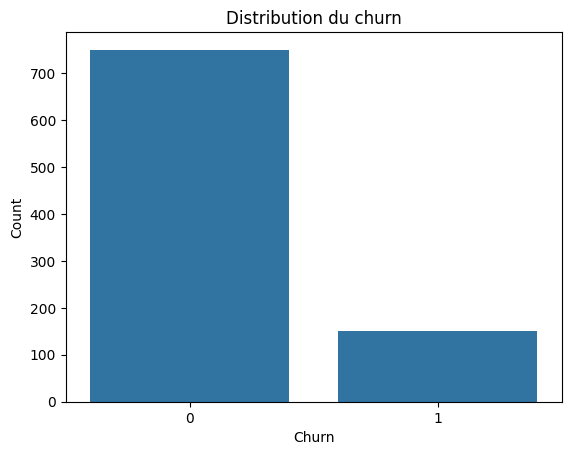

In [ ]:
# Visualiser la variable churn

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=dataset)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution du churn')
plt.show()

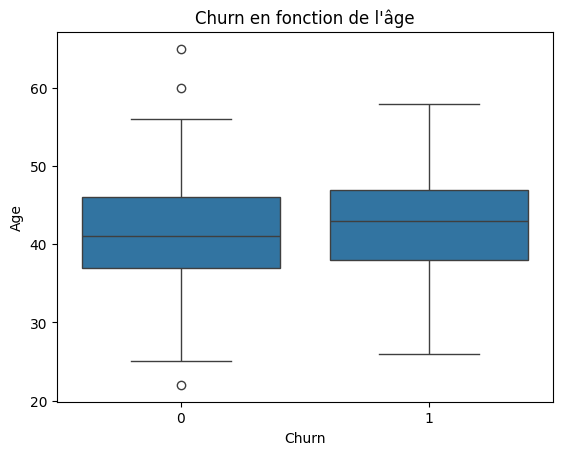

In [ ]:
# Visualiser le churn en fonction de l'âge

sns.boxplot(x='Churn', y='Age', data=dataset)
plt.xlabel  ('Churn')
plt.ylabel('Age')
plt.title("Churn en fonction de l'âge")
plt.show()

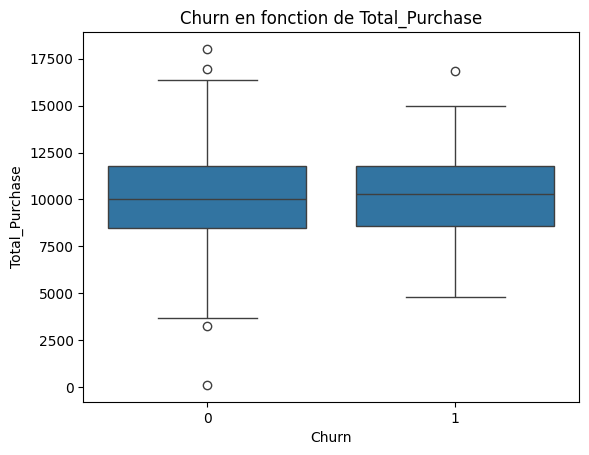

In [ ]:
# Visualiser le churn en fonction de Total_Purchase

sns.boxplot(x='Churn', y='Total_Purchase', data=dataset)
plt.xlabel('Churn')
plt.ylabel('Total_Purchase')
plt.title('Churn en fonction de Total_Purchase')
plt.show()

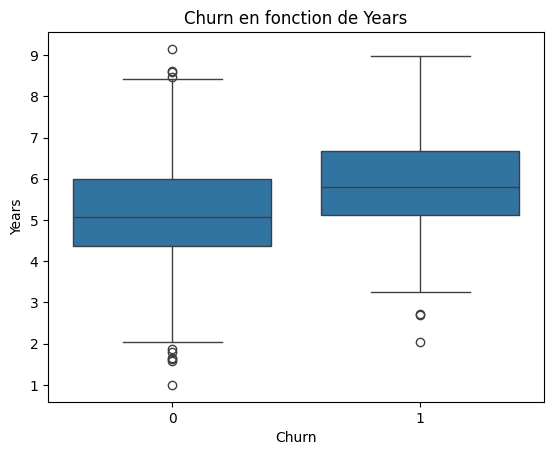

In [ ]:
# Visualiser le churn en fonction de Years

sns.boxplot(x='Churn', y='Years', data=dataset)
plt.xlabel('Churn')
plt.ylabel('Years')
plt.title('Churn en fonction de Years')
plt.show()

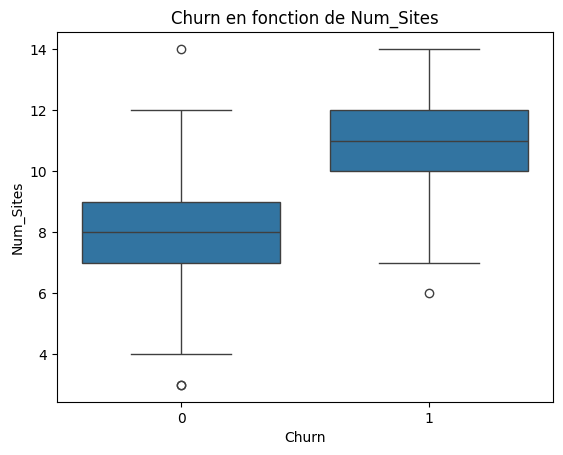

In [ ]:
# Visualiser le hcurn en fonction de Num_Sites

sns.boxplot(x='Churn', y='Num_Sites', data=dataset)
plt.xlabel('Churn')
plt.ylabel('Num_Sites')
plt.title('Churn en fonction de Num_Sites')
plt.show()

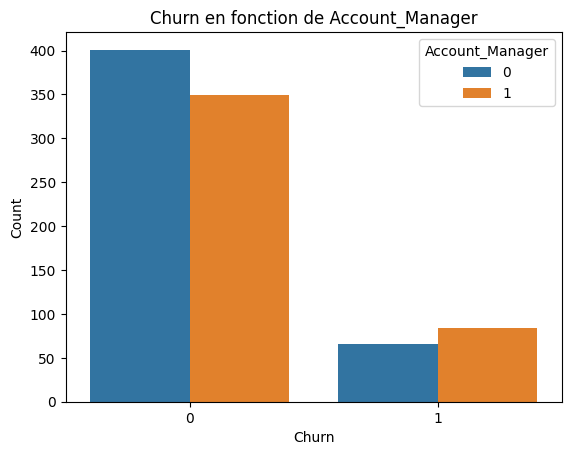

In [ ]:
# Visualiser le churn en fonction de Account Manager

sns.countplot(x='Churn', hue='Account_Manager', data=dataset)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn en fonction de Account_Manager')
plt.show()

## Modélisation

In [ ]:
# Isoler X et y

X = dataset.drop('Churn', axis=1)
y = dataset['Churn']


# Splitter en train et test


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
687,43.0,9891.30,0,5.75,11.0
705,46.0,7638.13,1,4.91,9.0
296,38.0,11803.58,1,6.97,6.0
172,43.0,6298.75,1,4.51,9.0
863,48.0,11316.41,1,4.74,10.0


In [ ]:
# Entraîner un modèle de régression logistique avec statsmodels

import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
log_reg = sm.Logit(y_train, X_train_sm).fit()

print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.259923
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                  630
Model:                          Logit   Df Residuals:                      624
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4295
Time:                        12:30:10   Log-Likelihood:                -163.75
converged:                       True   LL-Null:                       -287.05
Covariance Type:            nonrobust   LLR p-value:                 2.954e-51
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -20.0003      2.124     -9.417      0.000     -24.163     -15.838
Age           

In [ ]:
# Prédire sur l'échantillon de test

X_test_sm = sm.add_constant(X_test)
y_pred = log_reg.predict(X_test_sm)
y_pred

# Transformer les prédiction en variable binaire : 0 et 1

y_pred_binary = [1 if x > 0.25 else 0 for x in y_pred]

In [ ]:
# Calculer les performances prédictives du modèle : accuracy, precision, recall, f1 score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy: ", accuracy_score(y_test, y_pred_binary))
print("Precision: ", precision_score(y_test, y_pred_binary))
print("Recall: ", recall_score(y_test, y_pred_binary))
print("F1 score: ", f1_score(y_test, y_pred_binary))


Accuracy:  0.8925925925925926
Precision:  0.6346153846153846
Recall:  0.7674418604651163
F1 score:  0.6947368421052632


$$ precision = \frac{VP}{VP+FP}$$ \\

$$ recall = \frac{VP}{VP+FN}$$

In [ ]:
# Entrainer une régression logistique avec sklearn

from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardiser les données

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)


Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred)
Recall = recall_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)

print("Accuracy: ", Accuracy)
print("Precision: ", Precision)
print("Recall: ", Recall)
print("F1 score: ", F1_score)

Accuracy:  0.9
Precision:  0.7222222222222222
Recall:  0.6046511627906976
F1 score:  0.6582278481012658
